# Lecture 12 · Scalar RNN: forward pass, BPTT & gradient dynamics

**Goal** · run a scalar vanilla-RNN forward by hand (reproduce $h_1,h_2,h_3$), verify backprop-through-time against finite differences, see why the recurrent weight causes vanishing/exploding gradients, and check the LSTM cell's additive memory.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1 · Forward pass

$$h_t=\tanh(w_x x_t + w_h h_{t-1} + b),\quad w_x=1,\ w_h=0.5,\ b=0,\ h_0=0.$$

In [2]:
wx, wh, b = 1.0, 0.5, 0.0
xs = [1.0, 2.0, -1.0]
h = 0.0
print(' t   x_t     a_t      h_t')
for t, x in enumerate(xs, 1):
    a = wx * x + wh * h + b
    h = np.tanh(a)
    print(f' {t}  {x:4.0f}  {a:7.3f}  {h:7.3f}')
print('\nlecture: h1=0.762, h2=0.983, h3=-0.469')

 t   x_t     a_t      h_t
 1     1    1.000    0.762
 2     2    2.381    0.983
 3    -1   -0.508   -0.469

lecture: h1=0.762, h2=0.983, h3=-0.469


**Why it is memory** · $h_3=\tanh(x_3+0.5\,h_2)$ and $h_2$ already contains $x_1,x_2$, so $h_3$ depends on the whole past — not just $x_3$.

## 2 · BPTT = gradients accumulate over shared time steps

With loss $L=\tfrac12(h_T - y)^2$, the recurrent weight $w_h$ is reused every step, so its gradient is a *sum* over time. We compute it by unrolling the backward recurrence and check it against finite differences.

In [3]:
def forward_loss(wx, wh, b, xs, y=0.0):
    h, hs = 0.0, []
    for x in xs:
        a = wx * x + wh * h + b
        h = np.tanh(a); hs.append(h)
    return 0.5 * (h - y) ** 2, hs

def bptt_grad_wh(wx, wh, b, xs, y=0.0):
    L, hs = forward_loss(wx, wh, b, xs, y)
    T = len(xs)
    dh = hs[-1] - y            # dL/dh_T
    g_wh = 0.0
    for t in range(T - 1, -1, -1):
        da = dh * (1 - hs[t] ** 2)          # through tanh
        h_prev = hs[t - 1] if t > 0 else 0.0
        g_wh += da * h_prev                 # accumulate at shared w_h
        dh = da * wh                        # propagate to h_{t-1}
    return g_wh

ana = bptt_grad_wh(wx, wh, b, xs)
eps = 1e-6
num = (forward_loss(wx, wh + eps, b, xs)[0] - forward_loss(wx, wh - eps, b, xs)[0]) / (2 * eps)
print(f'BPTT dL/dw_h      = {ana:.6f}')
print(f'finite-difference = {num:.6f}   (match => BPTT is correct)')

BPTT dL/dw_h      = -0.364238
finite-difference = -0.364238   (match => BPTT is correct)


## 3 · Vanishing & exploding gradients

Along the recurrence the gradient carries a factor $\approx w_h^{T}$ (near $h\!\approx\!0$, $\tanh'\!\approx\!1$). Small $w_h$ → vanish, large $w_h$ → explode.

w=0.9, T=50:  w^T = 0.0052
w=1.1, T=50:  w^T = 117.3909
lecture: 0.9^50 ~ 0.005 (vanish), 1.1^50 ~ 117 (explode)


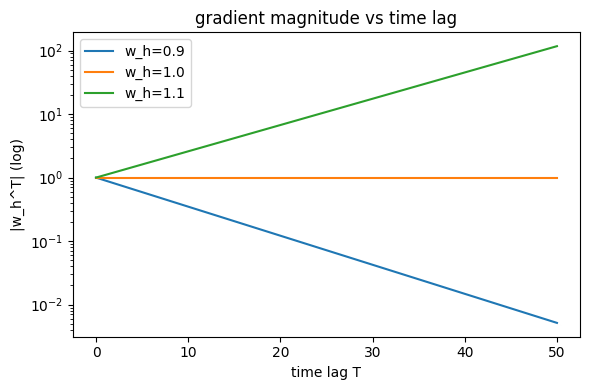

In [4]:
for w, T in [(0.9, 50), (1.1, 50)]:
    print(f'w={w}, T={T}:  w^T = {w**T:.4f}')
print('lecture: 0.9^50 ~ 0.005 (vanish), 1.1^50 ~ 117 (explode)')

Ts = np.arange(0, 51)
plt.figure(figsize=(6, 4))
for w in [0.9, 1.0, 1.1]:
    plt.semilogy(Ts, w ** Ts.astype(float), label=f'w_h={w}')
plt.xlabel('time lag T'); plt.ylabel('|w_h^T| (log)'); plt.legend()
plt.title('gradient magnitude vs time lag'); plt.tight_layout(); plt.show()

## 4 · Gradient clipping (for the exploding case)

If $\|g\|_2 > c$, rescale $g \leftarrow c\,g/\|g\|_2$: keep direction, cap magnitude.

In [5]:
g = np.array([6.0, 8.0]); c = 5.0
g_clip = g if np.linalg.norm(g) <= c else c * g / np.linalg.norm(g)
print('||g|| =', np.linalg.norm(g), '-> clipped g =', g_clip, ' (lecture [3, 4])')

||g|| = 10.0 -> clipped g = [3. 4.]  (lecture [3, 4])


## 5 · LSTM additive memory fixes vanishing

Cell update $c_t = f_t c_{t-1} + i_t \tilde c_t$ has $\partial c_t/\partial c_{t-1}=f_t$. With $f_t\approx1$ gradients flow without repeated multiplication by a recurrent matrix.

In [6]:
def cell(c_prev, f, i, c_tilde):
    return f * c_prev + i * c_tilde

print('retain : c_prev=5, f=0.8, i=0.2, c~=3  -> c_t =', cell(5, 0.8, 0.2, 3), '(lecture 4.6)')
print('replace: c_prev=5, f=0.1, i=0.9, c~=-2 -> c_t =', cell(5, 0.1, 0.9, -2), '(lecture -1.3)')
print('dc_t/dc_prev = f_t : ~1 keeps gradient alive across time')

retain : c_prev=5, f=0.8, i=0.2, c~=3  -> c_t = 4.6 (lecture 4.6)
replace: c_prev=5, f=0.1, i=0.9, c~=-2 -> c_t = -1.3 (lecture -1.3)
dc_t/dc_prev = f_t : ~1 keeps gradient alive across time


## Takeaway

- The RNN forward pass carries a hidden state that summarises the whole past.
- BPTT sums each shared parameter's gradient over time (verified vs finite differences).
- Repeated multiplication by $w_h$ makes gradients vanish ($<1$) or explode ($>1$); clipping caps the latter.
- The LSTM's additive cell path ($\partial c_t/\partial c_{t-1}=f_t$) keeps long-range gradients alive.